# Real-World Dataset Upgrade + Single-Notebook Benchmark

This notebook does everything in one place:
1. Loads baseline dataset (v1).
2. Builds a more real-world-like dataset variant (v2).
3. Trains DRL policies (Q-learning + Double-Q).
4. Evaluates baselines and DRL on v1 and v2 under the same stress grid.
5. Shows visual outputs for distributions, training behavior, leaderboard, and significance.

In [1]:
from __future__ import annotations

import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STEP_MINUTES = 5
STEP_HOURS = STEP_MINUTES / 60.0
HORIZON_STEPS = 288

OVERALL_WEIGHTS = {
    "carbon": 0.35,
    "jct": 0.20,
    "tail": 0.25,
    "preempt": 0.10,
    "starvation": 0.10,
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 110

print("Setup ready. Seed =", SEED)

Setup ready. Seed = 42


In [2]:
def resolve_clean_dataset() -> Path:
    candidates = [
        Path("../../clean_dataset.csv"),
        Path("../clean_dataset.csv"),
        Path("clean_dataset.csv"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find clean_dataset.csv. Checked: {candidates}")


def load_and_prepare_v1() -> pd.DataFrame:
    path = resolve_clean_dataset()
    df = pd.read_csv(path)
    required = {"job_name", "task_name", "start_time", "duration", "energy", "plan_cpu"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = df.dropna(subset=["start_time", "duration", "energy", "plan_cpu"]).copy()
    df["duration"] = df["duration"].clip(lower=1)
    df["energy"] = df["energy"].clip(lower=1e-6)
    df["plan_cpu"] = df["plan_cpu"].clip(lower=1.0)
    df["power_proxy"] = df["energy"] / df["duration"]
    return df


v1_df = load_and_prepare_v1()
print(f"Loaded baseline dataset rows: {len(v1_df):,}")
display(v1_df[["duration", "energy", "plan_cpu", "power_proxy"]].describe().round(3))

Loaded baseline dataset rows: 46,533


,duration,energy,plan_cpu,power_proxy
count,46533.000,46533.000,46533.000,46533.000
mean,59.846,4.353,83.826,0.084
std,129.145,11.869,62.826,0.063
min,1.000,0.020,5.000,0.005
25%,3.000,0.200,50.000,0.050
50%,9.000,0.600,100.000,0.100
75%,43.000,2.940,100.000,0.100
max,985.000,566.300,700.000,0.700


Saved real-world-like dataset to: ..\data\clean_dataset_realworld_v2.csv
v1 rows=46,533 | v2 rows=49,314


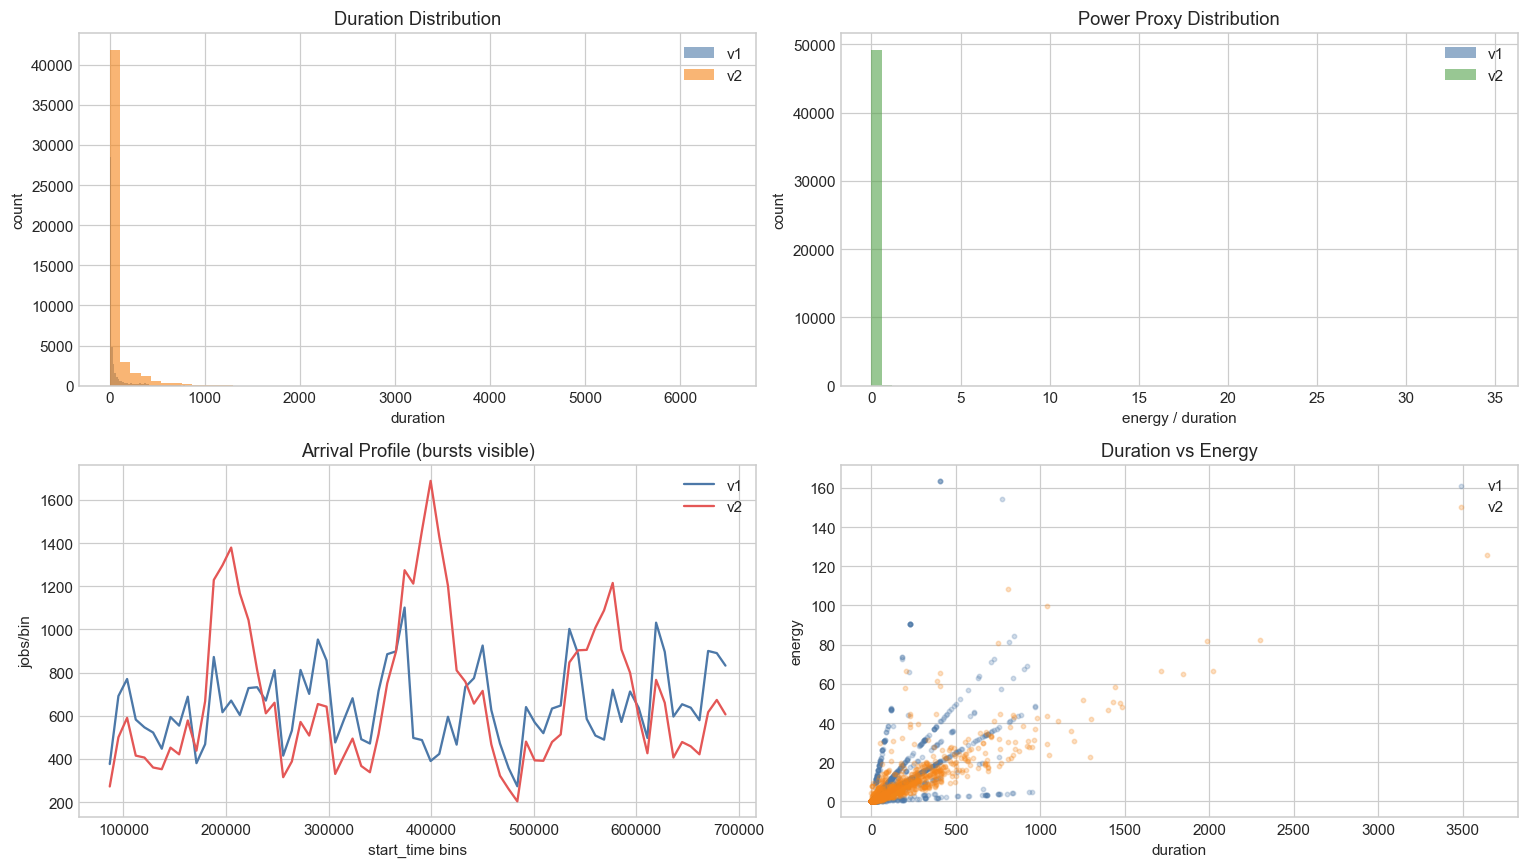

In [9]:
def create_realworld_like_dataset(df: pd.DataFrame, seed: int = 31415) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    out = df.copy().reset_index(drop=True)
    n = len(out)

    # 1) Long-tail and short-interactive duration perturbations
    out["duration"] = out["duration"].astype(float)
    long_mask = rng.random(n) < 0.24
    short_mask = (~long_mask) & (rng.random(n) < 0.18)

    out.loc[long_mask, "duration"] = np.clip(
        out.loc[long_mask, "duration"] * rng.lognormal(mean=0.45, sigma=0.55, size=long_mask.sum()),
        1,
        np.quantile(out["duration"], 0.995) * 6.0,
    )
    out.loc[short_mask, "duration"] = np.clip(
        out.loc[short_mask, "duration"] * rng.uniform(0.35, 0.78, size=short_mask.sum()),
        1,
        None,
    )

    # 2) Burst arrivals around a few time windows
    smin = float(out["start_time"].min())
    smax = float(out["start_time"].max())
    span = max(1.0, smax - smin)
    burst_centers = np.array([smin + 0.20 * span, smin + 0.52 * span, smin + 0.80 * span])
    burst_mask = rng.random(n) < 0.32
    selected_centers = rng.choice(burst_centers, size=burst_mask.sum(), p=[0.30, 0.45, 0.25])
    jitter = rng.normal(0.0, 0.03 * span, size=burst_mask.sum())
    out.loc[burst_mask, "start_time"] = np.clip(selected_centers + jitter, smin, smax).astype(int)

    # 3) Non-linear energy behavior with CPU/duration interaction and burst overhead
    cpu_norm = (out["plan_cpu"] / out["plan_cpu"].max()).clip(lower=0.05).to_numpy()
    dur = out["duration"].astype(float).to_numpy()
    baseline = out["energy"].astype(float).to_numpy()

    nonlinear = (0.012 * (dur ** 1.16)) * (1.0 + 0.35 * cpu_norm)
    burst_factor = np.ones(n, dtype=float)
    burst_factor[burst_mask] = rng.uniform(1.03, 1.20, size=burst_mask.sum())
    noise_factor = rng.normal(1.0, 0.07, size=n)

    out["energy"] = np.clip((0.35 * baseline + 0.65 * nonlinear) * burst_factor * noise_factor, 1e-6, None)

    # 4) Telemetry imperfections (small missingness + jitter)
    miss_mask = rng.random(n) < 0.02
    out.loc[miss_mask, "energy"] = np.nan
    out["energy"] = out["energy"].interpolate(limit_direction="both")

    cpu_jitter_mask = rng.random(n) < 0.10
    out.loc[cpu_jitter_mask, "plan_cpu"] = np.clip(
        out.loc[cpu_jitter_mask, "plan_cpu"] * rng.normal(1.0, 0.10, size=cpu_jitter_mask.sum()),
        10.0,
        100.0,
    )

    # 5) Retry/failure behavior: replicate subset with delayed submit and overhead
    retry_mask = rng.random(n) < 0.06
    retries = out.loc[retry_mask].copy()
    if len(retries) > 0:
        retries["task_name"] = retries["task_name"].astype(str) + "_retry"
        retries["start_time"] = retries["start_time"].astype(float) + rng.integers(8, 160, size=len(retries))
        retries["duration"] = np.clip(retries["duration"] * rng.uniform(1.15, 1.85, size=len(retries)), 1, None)
        retries["energy"] = np.clip(retries["energy"] * rng.uniform(1.10, 1.40, size=len(retries)), 1e-6, None)
        out = pd.concat([out, retries], ignore_index=True)

    out["duration"] = out["duration"].round().clip(lower=1).astype(int)
    out["plan_cpu"] = out["plan_cpu"].round(2)
    out["end_time"] = (out["start_time"].astype(float) + out["duration"].astype(float)).round().astype(int)
    out["energy"] = out["energy"].clip(lower=1e-6)
    out["power_proxy"] = out["energy"] / out["duration"].clip(lower=1)

    out = out.sort_values("start_time").reset_index(drop=True)
    return out


def arrival_profile(df: pd.DataFrame, bins: int = 48):
    counts, edges = np.histogram(df["start_time"].to_numpy(), bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts


v2_df = create_realworld_like_dataset(v1_df)
save_dir = Path("../data")
save_dir.mkdir(parents=True, exist_ok=True)
v2_path = save_dir / "clean_dataset_realworld_v2.csv"
v2_df.to_csv(v2_path, index=False)
print("Saved real-world-like dataset to:", v2_path)
print(f"v1 rows={len(v1_df):,} | v2 rows={len(v2_df):,}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=110)

axes[0, 0].hist(v1_df["duration"], bins=60, alpha=0.6, label="v1", color="#4C78A8")
axes[0, 0].hist(v2_df["duration"], bins=60, alpha=0.6, label="v2", color="#F58518")
axes[0, 0].set_title("Duration Distribution")
axes[0, 0].set_xlabel("duration")
axes[0, 0].set_ylabel("count")
axes[0, 0].legend()

axes[0, 1].hist(v1_df["power_proxy"], bins=60, alpha=0.6, label="v1", color="#4C78A8")
axes[0, 1].hist(v2_df["power_proxy"], bins=60, alpha=0.6, label="v2", color="#54A24B")
axes[0, 1].set_title("Power Proxy Distribution")
axes[0, 1].set_xlabel("energy / duration")
axes[0, 1].set_ylabel("count")
axes[0, 1].legend()

c1, a1 = arrival_profile(v1_df, bins=72)
c2, a2 = arrival_profile(v2_df, bins=72)
axes[1, 0].plot(c1, a1, label="v1", color="#4C78A8")
axes[1, 0].plot(c2, a2, label="v2", color="#E45756")
axes[1, 0].set_title("Arrival Profile (bursts visible)")
axes[1, 0].set_xlabel("start_time bins")
axes[1, 0].set_ylabel("jobs/bin")
axes[1, 0].legend()

sample_v1 = v1_df.sample(n=min(3000, len(v1_df)), random_state=SEED)
sample_v2 = v2_df.sample(n=min(3000, len(v2_df)), random_state=SEED)
axes[1, 1].scatter(sample_v1["duration"], sample_v1["energy"], s=8, alpha=0.25, label="v1", color="#4C78A8")
axes[1, 1].scatter(sample_v2["duration"], sample_v2["energy"], s=8, alpha=0.25, label="v2", color="#F58518")
axes[1, 1].set_title("Duration vs Energy")
axes[1, 1].set_xlabel("duration")
axes[1, 1].set_ylabel("energy")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [4]:
@dataclass
class Job:
    job_id: int
    submit_step: int
    duration_steps: int
    power_kw: float


def make_workload(congestion: str, horizon_steps: int, rng: np.random.Generator) -> list[Job]:
    rates = {"light": 0.20, "moderate": 0.38, "high": 0.55}
    rate = rates[congestion]
    jobs = []
    jid = 0
    for step in range(horizon_steps):
        if rng.random() < rate:
            duration = int(rng.integers(6, 42))
            power = float(rng.choice([1.2, 2.0, 3.2], p=[0.35, 0.45, 0.20]))
            jobs.append(Job(job_id=jid, submit_step=step, duration_steps=duration, power_kw=power))
            jid += 1
    if not jobs:
        jobs = [Job(job_id=0, submit_step=0, duration_steps=10, power_kw=2.0)]
    return jobs


def make_workload_from_dataset(congestion: str, horizon_steps: int, rng: np.random.Generator, df: pd.DataFrame) -> list[Job]:
    jobs_per_regime = {"light": 90, "moderate": 160, "high": 250}
    n = jobs_per_regime[congestion]
    sampled = df.sample(n=n, replace=True, random_state=int(rng.integers(1, 1_000_000))).copy()

    smin, smax = float(df["start_time"].min()), float(df["start_time"].max())
    denom = max(1.0, smax - smin)
    sampled["submit_step"] = ((sampled["start_time"] - smin) / denom * (horizon_steps - 1)).round().astype(int)
    sampled["duration_steps"] = np.clip((sampled["duration"] / STEP_MINUTES).round().astype(int), 3, 120)

    q1 = sampled["power_proxy"].quantile(0.33)
    q2 = sampled["power_proxy"].quantile(0.66)

    def to_band(v: float) -> float:
        if v <= q1:
            return 1.2
        if v <= q2:
            return 2.0
        return 3.2

    sampled["power_kw"] = sampled["power_proxy"].apply(to_band)

    jobs = []
    for i, row in enumerate(sampled.itertuples(index=False)):
        jobs.append(Job(i, int(row.submit_step), int(row.duration_steps), float(row.power_kw)))
    return jobs


def build_jobs(congestion: str, horizon_steps: int, rng: np.random.Generator, source: str, df: pd.DataFrame) -> list[Job]:
    if source == "synthetic":
        return make_workload(congestion, horizon_steps, rng)
    if source == "dataset":
        return make_workload_from_dataset(congestion, horizon_steps, rng, df)
    raise ValueError(f"Unknown source: {source}")


def make_carbon_curve(horizon_steps: int, noise_pct: float, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(horizon_steps)
    base = 260 + 120 * np.sin((2 * np.pi * t / horizon_steps) - (np.pi / 2))
    noise = rng.normal(0.0, (noise_pct / 100.0) * base)
    return np.clip(base + noise, 80, 650).astype(float)


def make_carbon_curve_stress(horizon_steps: int, rng: np.random.Generator, noise_pct: float = 10.0) -> np.ndarray:
    curve = make_carbon_curve(horizon_steps, noise_pct, rng).copy()
    n_spikes = max(1, int(0.03 * horizon_steps))
    n_dips = max(1, int(0.02 * horizon_steps))
    spike_idx = rng.choice(np.arange(horizon_steps), size=n_spikes, replace=False)
    dip_idx = rng.choice(np.arange(horizon_steps), size=n_dips, replace=False)
    curve[spike_idx] += rng.uniform(80, 180, size=len(spike_idx))
    curve[dip_idx] -= rng.uniform(40, 100, size=len(dip_idx))
    return np.clip(curve, 80, 650)


def apply_workload_shocks(jobs: list[Job], rng: np.random.Generator, horizon_steps: int) -> list[Job]:
    if not jobs:
        return jobs

    shocked = []
    burst_center = int(rng.integers(int(0.25 * horizon_steps), int(0.75 * horizon_steps)))
    burst_half_window = 12

    for j in jobs:
        submit_step = j.submit_step
        duration_steps = j.duration_steps
        power_kw = j.power_kw

        if rng.random() < 0.30:
            submit_step = int(np.clip(rng.integers(burst_center - burst_half_window, burst_center + burst_half_window + 1), 0, horizon_steps - 1))
        if rng.random() < 0.12:
            duration_steps = int(np.clip(duration_steps * rng.uniform(1.4, 2.8), 3, 140))
        if rng.random() < 0.20:
            power_kw = float(np.clip(power_kw * rng.uniform(0.9, 1.25), 1.0, 4.0))

        shocked.append(Job(j.job_id, submit_step, duration_steps, power_kw))

    return shocked


class SimpleClusterEnv:
    def __init__(self, jobs: list[Job], carbon_curve: np.ndarray, capacity: int = 8, reward_weights: Optional[Dict[str, float]] = None):
        self.jobs = {j.job_id: j for j in jobs}
        self.job_order = sorted(jobs, key=lambda x: x.submit_step)
        self.curve = carbon_curve
        self.capacity = capacity
        self.max_step = len(carbon_curve)
        self.median_ci = float(np.median(carbon_curve))
        self.weights = reward_weights or OVERALL_WEIGHTS
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.arrival_ptr = 0
        self.waiting = set()
        self.running = set()
        self.remaining = {jid: self.jobs[jid].duration_steps for jid in self.jobs}
        self.submit = {jid: self.jobs[jid].submit_step for jid in self.jobs}
        self.finish = {}
        self.prev_running = set()

        self.total_carbon_kg = 0.0
        self.total_preemptions = 0
        self.total_wait_steps = 0
        self.total_starvation_penalty = 0.0

        self.done = False
        return self._state()

    def _add_arrivals(self):
        while self.arrival_ptr < len(self.job_order) and self.job_order[self.arrival_ptr].submit_step <= self.step_idx:
            jid = self.job_order[self.arrival_ptr].job_id
            if jid not in self.finish:
                self.waiting.add(jid)
            self.arrival_ptr += 1

    def _active_jobs(self):
        return [jid for jid in self.jobs if jid not in self.finish and self.submit[jid] <= self.step_idx]

    def _state(self):
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        ci_norm = (ci - 80) / (650 - 80)

        queue_len = len(self.waiting)
        run_len = len(self.running)
        util = run_len / max(1, self.capacity)
        load = min(queue_len / (2 * max(1, self.capacity)), 1.0)

        if self.waiting:
            ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            p90_wait = float(np.percentile(ages, 90)) / 96.0
        else:
            p90_wait = 0.0

        active = self._active_jobs()
        if active:
            long_ratio = float(np.mean([1.0 if self.remaining[j] >= 24 else 0.0 for j in active]))
        else:
            long_ratio = 0.0

        return np.array([ci_norm, load, util, min(1.0, p90_wait), long_ratio], dtype=np.float32)

    def _policy_rank(self, policy_name: str):
        active = self._active_jobs()
        ci_now = self.curve[min(self.step_idx, self.max_step - 1)]

        if policy_name == "fcfs":
            ranked = sorted(active, key=lambda jid: (self.submit[jid], jid))
        elif policy_name == "carbon":
            if ci_now > self.median_ci:
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (-self.jobs[jid].power_kw, self.submit[jid]))
        elif policy_name == "srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        elif policy_name == "aged_srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid] - 0.15 * max(0, self.step_idx - self.submit[jid]), self.submit[jid]))
        elif policy_name == "carbon_guarded_short":
            if ci_now >= float(np.quantile(self.curve, 0.85)):
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        return ranked[: self.capacity]

    def step(self, action_idx: int):
        self._add_arrivals()

        action_map = {0: "fcfs", 1: "carbon", 2: "srtf", 3: "aged_srtf", 4: "carbon_guarded_short"}
        selected = set(self._policy_rank(action_map[action_idx]))

        preemptions = len(self.prev_running - selected)
        self.total_preemptions += preemptions

        for jid in self._active_jobs():
            if jid in selected:
                self.running.add(jid)
                self.waiting.discard(jid)
            else:
                self.running.discard(jid)
                self.waiting.add(jid)

        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        step_carbon_kg = 0.0

        finished_now = []
        for jid in list(self.running):
            self.remaining[jid] -= 1
            step_carbon_kg += (self.jobs[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if self.remaining[jid] <= 0:
                finished_now.append(jid)

        for jid in finished_now:
            self.finish[jid] = self.step_idx
            self.running.discard(jid)
            self.waiting.discard(jid)

        self.total_wait_steps += len(self.waiting)
        self.total_carbon_kg += step_carbon_kg

        if self.waiting:
            wait_ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            tail_wait = float(np.percentile(wait_ages, 90))
            starvation_ratio = float(np.mean([1.0 if w >= 18 else 0.0 for w in wait_ages]))
        else:
            tail_wait = 0.0
            starvation_ratio = 0.0

        self.total_starvation_penalty += starvation_ratio

        cost = (
            self.weights.get("carbon", 0.0) * step_carbon_kg
            + self.weights.get("jct", 0.0) * (len(self.waiting) + 0.25 * len(self.running))
            + self.weights.get("tail", 0.0) * tail_wait
            + self.weights.get("preempt", 0.0) * (preemptions / max(1, self.capacity))
            + self.weights.get("starvation", 0.0) * starvation_ratio
        )
        reward = -cost

        self.prev_running = set(self.running)
        self.step_idx += 1

        no_future_arrivals = self.arrival_ptr >= len(self.job_order)
        no_active_jobs = len(self.waiting) == 0 and len(self.running) == 0
        self.done = (self.step_idx >= self.max_step) or (no_future_arrivals and no_active_jobs)

        return self._state(), reward, self.done, {}

    def metrics(self):
        completed_jcts = []
        for jid, finish_step in self.finish.items():
            jct = max(1, finish_step - self.submit[jid] + 1)
            completed_jcts.append(jct * STEP_HOURS)

        if completed_jcts:
            avg_jct_h = float(np.mean(completed_jcts))
            tail_jct_h = float(np.percentile(completed_jcts, 95))
        else:
            avg_jct_h = np.nan
            tail_jct_h = np.nan

        return {
            "jobs_total": len(self.jobs),
            "jobs_completed": len(self.finish),
            "carbon_kg": self.total_carbon_kg,
            "avg_jct_h": avg_jct_h,
            "tail_jct_h": tail_jct_h,
            "preemptions": self.total_preemptions,
            "avg_wait_h": (self.total_wait_steps * STEP_HOURS) / max(1, len(self.jobs)),
            "starvation_penalty": self.total_starvation_penalty / max(1, self.max_step),
        }


def discretize_state(state_vec: np.ndarray):
    ci, load, util, p90_wait, long_ratio = state_vec
    ci_bin = min(int(ci * 4), 3)
    load_bin = min(int(load * 4), 3)
    util_bin = 0 if util < 0.5 else 1
    wait_bin = min(int(p90_wait * 3), 2)
    long_bin = min(int(long_ratio * 3), 2)
    return (ci_bin, load_bin, util_bin, wait_bin, long_bin)


print("Simulator core ready.")

Simulator core ready.


In [5]:
def train_q_domain_randomized(
    df: pd.DataFrame,
    episodes: int = 90,
    alpha: float = 0.12,
    gamma: float = 0.97,
    hard_bias: float = 0.70,
    reward_weights: Optional[Dict[str, float]] = None,
    seed_offset: int = 70_000,
):
    q = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    history = []

    for ep in range(episodes):
        rng = np.random.default_rng(seed_offset + ep)
        eps = 0.04 + (1.0 - 0.04) * np.exp(-4.0 * ep / max(1, episodes))

        if rng.random() < hard_bias:
            congestion = "high"
            noise = float(rng.choice([15.0, 20.0, 25.0], p=[0.30, 0.45, 0.25]))
            capacity = int(rng.choice([6, 8], p=[0.75, 0.25]))
        else:
            congestion = str(rng.choice(["light", "moderate", "high"], p=[0.20, 0.45, 0.35]))
            noise = float(rng.choice([5.0, 10.0, 15.0, 20.0], p=[0.2, 0.3, 0.3, 0.2]))
            capacity = int(rng.choice([6, 8, 10], p=[0.25, 0.60, 0.15]))

        source = "dataset" if rng.random() < 0.85 else "synthetic"
        jobs = build_jobs(congestion, HORIZON_STEPS, rng, source, df)
        if rng.random() < 0.70:
            jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)

        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=reward_weights or OVERALL_WEIGHTS)

        state = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            s = discretize_state(state)
            if rng.random() < eps:
                action = int(rng.integers(0, 5))
            else:
                action = int(np.argmax(q[s]))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)
            td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
            q[s + (action,)] += alpha * (td_target - q[s + (action,)])

            ep_reward += reward
            state = next_state

        m = env.metrics()
        history.append({
            "episode": ep,
            "reward": ep_reward,
            "carbon_kg": m["carbon_kg"],
            "avg_jct_h": m["avg_jct_h"],
            "tail_jct_h": m["tail_jct_h"],
            "hard_episode": int(congestion == "high" and noise >= 20.0 and capacity == 6),
        })

    return q, pd.DataFrame(history)


def collect_srtf_demo_counts(df: pd.DataFrame, episodes: int = 50) -> np.ndarray:
    counts = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    for ep in range(episodes):
        rng = np.random.default_rng(93_000 + ep)
        congestion = str(rng.choice(["moderate", "high"], p=[0.40, 0.60]))
        noise = float(rng.choice([15.0, 20.0, 25.0], p=[0.25, 0.50, 0.25]))
        capacity = int(rng.choice([6, 8], p=[0.75, 0.25]))

        jobs = build_jobs(congestion, HORIZON_STEPS, rng, "dataset", df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)

        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
        state = env.reset()
        done = False

        while not done:
            s = discretize_state(state)
            expert_action = 2
            counts[s + (expert_action,)] += 1.0
            state, _, done, _ = env.step(expert_action)

    return counts


def train_double_q(
    df: pd.DataFrame,
    episodes: int = 110,
    alpha: float = 0.10,
    gamma: float = 0.98,
    q_init: Optional[np.ndarray] = None,
    reward_weights: Optional[Dict[str, float]] = None,
):
    q1 = np.zeros((4, 4, 2, 3, 3, 5), dtype=np.float32)
    q2 = np.zeros_like(q1)
    if q_init is not None:
        q1 += q_init
        q2 += q_init

    history = []

    for ep in range(episodes):
        rng = np.random.default_rng(95_000 + ep)
        eps = 0.03 + (1.0 - 0.03) * np.exp(-4.0 * ep / max(1, episodes))

        congestion = str(rng.choice(["moderate", "high"], p=[0.35, 0.65]))
        noise = float(rng.choice([15.0, 20.0, 25.0], p=[0.25, 0.50, 0.25]))
        capacity = int(rng.choice([6, 8], p=[0.80, 0.20]))

        jobs = build_jobs(congestion, HORIZON_STEPS, rng, "dataset", df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)

        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=reward_weights or OVERALL_WEIGHTS)
        state = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            s = discretize_state(state)
            q_sum = q1[s] + q2[s]
            if rng.random() < eps:
                action = int(rng.integers(0, 5))
            else:
                action = int(np.argmax(q_sum))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)

            if rng.random() < 0.5:
                a_star = int(np.argmax(q1[ns]))
                td_target = reward + (0.0 if done else gamma * float(q2[ns + (a_star,)]))
                q1[s + (action,)] += alpha * (td_target - q1[s + (action,)])
            else:
                a_star = int(np.argmax(q2[ns]))
                td_target = reward + (0.0 if done else gamma * float(q1[ns + (a_star,)]))
                q2[s + (action,)] += alpha * (td_target - q2[s + (action,)])

            ep_reward += reward
            state = next_state

        m = env.metrics()
        history.append({
            "episode": ep,
            "reward": ep_reward,
            "carbon_kg": m["carbon_kg"],
            "avg_jct_h": m["avg_jct_h"],
            "tail_jct_h": m["tail_jct_h"],
        })

    return (q1 + q2) / 2.0, pd.DataFrame(history)


def run_policy_inference(
    df: pd.DataFrame,
    policy_name: str,
    seed: int,
    q_table: Optional[np.ndarray],
    noise_pct: float,
    congestion: str,
    capacity: int,
    reward_weights: Optional[Dict[str, float]] = None,
):
    rng = np.random.default_rng(seed)
    jobs = build_jobs(congestion, HORIZON_STEPS, rng, "dataset", df)
    jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
    curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise_pct)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=reward_weights or OVERALL_WEIGHTS)
    state = env.reset()
    done = False

    fixed_map = {"fcfs": 0, "carbon": 1, "srtf": 2}

    while not done:
        if policy_name in fixed_map:
            action = fixed_map[policy_name]
        elif policy_name.startswith("q_"):
            if q_table is None:
                raise ValueError("q_table required for learned policy")
            action = int(np.argmax(q_table[discretize_state(state)]))
        else:
            raise ValueError(f"Unknown policy {policy_name}")

        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update({
        "policy": policy_name,
        "seed": seed,
        "noise_pct": noise_pct,
        "congestion": congestion,
        "capacity": capacity,
    })
    return out


def evaluate_policies(
    df: pd.DataFrame,
    policy_tables: Dict[str, Optional[np.ndarray]],
    seeds: list[int],
    noises: list[float],
    congestions: list[str],
    capacities: list[int],
    reward_weights: Optional[Dict[str, float]] = None,
) -> pd.DataFrame:
    rows = []
    for seed in seeds:
        for noise in noises:
            for cong in congestions:
                for cap in capacities:
                    for policy, q_table in policy_tables.items():
                        rows.append(
                            run_policy_inference(
                                df=df,
                                policy_name=policy,
                                seed=seed,
                                q_table=q_table,
                                noise_pct=noise,
                                congestion=cong,
                                capacity=cap,
                                reward_weights=reward_weights,
                            )
                        )
    return pd.DataFrame(rows)


def normalize_metric_by_scenario(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.Series:
    gmin = df.groupby(group_cols)[metric].transform("min")
    gmax = df.groupby(group_cols)[metric].transform("max")
    return np.where((gmax - gmin) > 1e-12, (df[metric] - gmin) / (gmax - gmin), 0.0)


def compute_overall_score_robust(detail: pd.DataFrame, weights: Dict[str, float]) -> pd.DataFrame:
    out = detail.copy()
    out["starvation_penalty"] = out["starvation_penalty"].fillna(out["avg_wait_h"].fillna(0.0))

    out["carbon_per_completed_job"] = out["carbon_kg"] / out["jobs_completed"].clip(lower=1)
    out["preempt_per_completed_job"] = out["preemptions"] / out["jobs_completed"].clip(lower=1)

    scenario_cols = ["seed", "noise_pct", "congestion", "capacity"]
    if "dataset_track" in out.columns:
        scenario_cols = ["dataset_track"] + scenario_cols

    out["n_carbon"] = normalize_metric_by_scenario(out, "carbon_per_completed_job", scenario_cols)
    out["n_avg_jct"] = normalize_metric_by_scenario(out, "avg_jct_h", scenario_cols)
    out["n_tail_jct"] = normalize_metric_by_scenario(out, "tail_jct_h", scenario_cols)
    out["n_preempt"] = normalize_metric_by_scenario(out, "preempt_per_completed_job", scenario_cols)
    out["n_starvation"] = normalize_metric_by_scenario(out, "starvation_penalty", scenario_cols)

    out["overall_score"] = (
        weights["carbon"] * out["n_carbon"]
        + weights["jct"] * out["n_avg_jct"]
        + weights["tail"] * out["n_tail_jct"]
        + weights["preempt"] * out["n_preempt"]
        + weights["starvation"] * out["n_starvation"]
    )
    return out


def bootstrap_mean_diff_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 3000, seed: int = 42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    obs = float(np.mean(a) - np.mean(b))

    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.mean(sa) - np.mean(sb)

    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p_two = 2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0))
    return obs, float(lo), float(hi), float(p_two)


print("Training and evaluation helpers ready.")

Training and evaluation helpers ready.


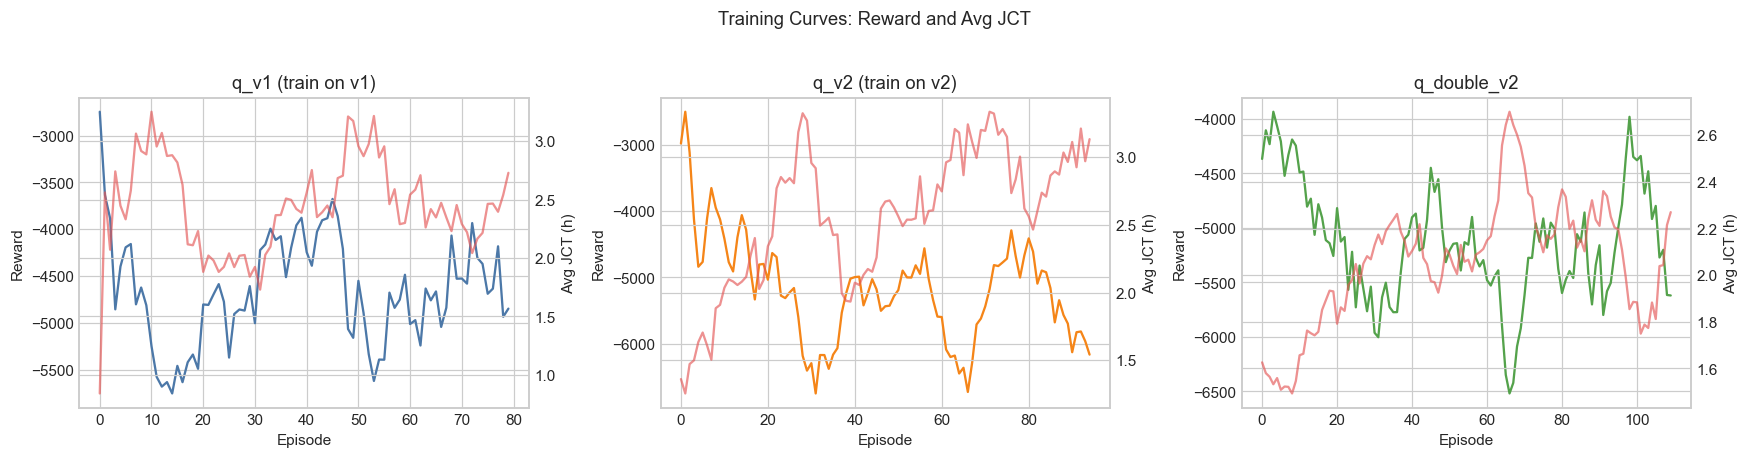

Training completed: q_v1, q_v2, q_double_v2


In [6]:
# Train baseline DRL on v1
q_v1, hist_v1 = train_q_domain_randomized(
    df=v1_df,
    episodes=80,
    hard_bias=0.65,
    reward_weights=OVERALL_WEIGHTS,
    seed_offset=70_000,
)

# Train upgraded DRL on v2
q_v2, hist_v2 = train_q_domain_randomized(
    df=v2_df,
    episodes=95,
    hard_bias=0.80,
    reward_weights=OVERALL_WEIGHTS,
    seed_offset=80_000,
)

# Imitation warm-start + Double-Q on v2
demo_counts = collect_srtf_demo_counts(v2_df, episodes=50)
q_init = demo_counts / np.maximum(1.0, demo_counts.sum(axis=-1, keepdims=True))
q_double_v2, hist_double_v2 = train_double_q(
    df=v2_df,
    episodes=110,
    q_init=q_init,
    reward_weights=OVERALL_WEIGHTS,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=110)

for ax, hist, label, color in [
    (axes[0], hist_v1, "q_v1 (train on v1)", "#4C78A8"),
    (axes[1], hist_v2, "q_v2 (train on v2)", "#F58518"),
    (axes[2], hist_double_v2, "q_double_v2", "#54A24B"),
]:
    ax.plot(hist["episode"], hist["reward"].rolling(10, min_periods=1).mean(), color=color, label="reward (rolling)")
    ax2 = ax.twinx()
    ax2.plot(hist["episode"], hist["avg_jct_h"].rolling(10, min_periods=1).mean(), color="#E45756", alpha=0.65, label="avg_jct_h (rolling)")
    ax.set_title(label)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax2.set_ylabel("Avg JCT (h)")

plt.suptitle("Training Curves: Reward and Avg JCT", y=1.03)
plt.tight_layout()
plt.show()

print("Training completed: q_v1, q_v2, q_double_v2")

Hard-slice leaderboard (lower overall score is better):


,dataset_track,policy,overall_score_mean,overall_score_ci95,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,jobs_completed_mean
44,v1_clean,srtf,0.1215,0.0054,0.2715,1.0614,4.7705,220.3333
20,v1_clean,q_double_v2,0.2357,0.0506,0.2821,1.7820,6.4486,208.5000
28,v1_clean,q_v1,0.2459,0.0434,0.2738,1.8953,7.0924,208.6667
36,v1_clean,q_v2,0.3046,0.0931,0.2896,2.2009,7.3767,204.5000
12,v1_clean,fcfs,0.7678,0.0210,0.4738,4.5699,10.7201,123.2500
4,v1_clean,carbon,0.8135,0.0216,0.4281,3.9733,11.8826,130.5000
92,v2_realworld,srtf,0.1187,0.0043,0.3474,1.0911,4.6944,218.0000
68,v2_realworld,q_double_v2,0.2458,0.0488,0.3607,1.8448,6.5969,204.7500
84,v2_realworld,q_v2,0.2673,0.0635,0.3485,2.1502,6.9767,211.8333
76,v2_realworld,q_v1,0.2728,0.0401,0.3551,1.9581,7.5625,205.2500


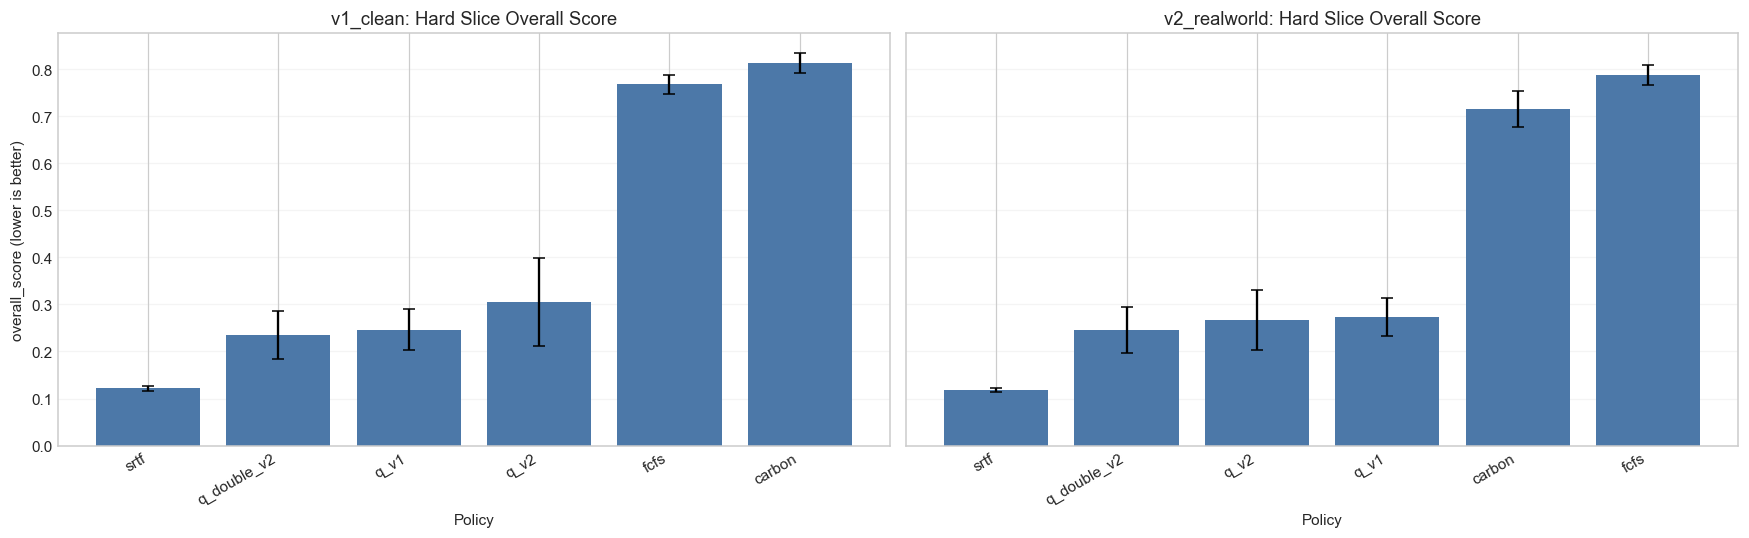

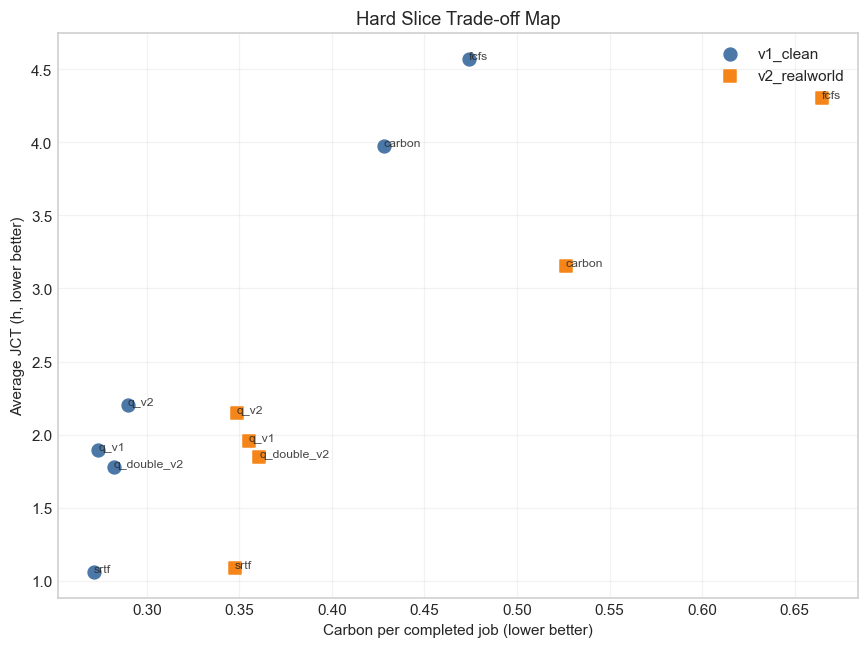

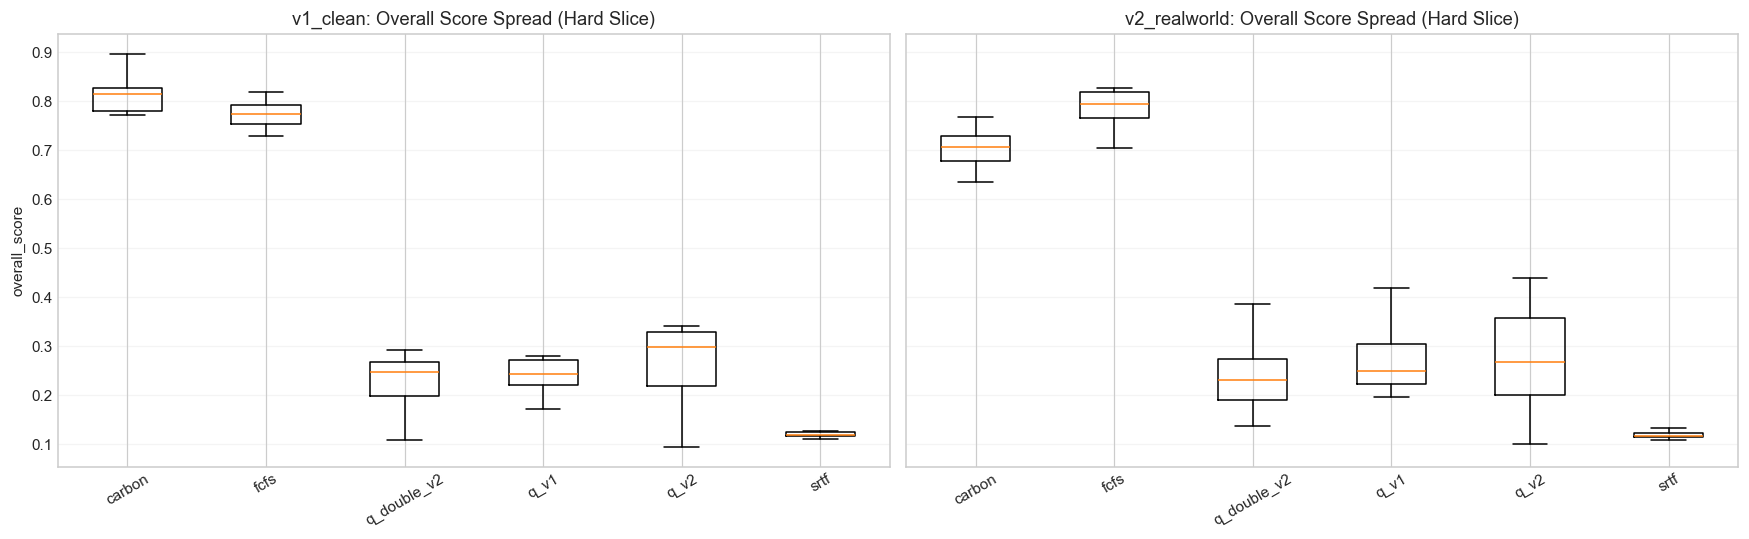

In [10]:
policy_tables = {
    "fcfs": None,
    "carbon": None,
    "srtf": None,
    "q_v1": q_v1,
    "q_v2": q_v2,
    "q_double_v2": q_double_v2,
}

eval_cfg = {
    "seeds": list(range(12)),
    "noises": [10.0, 20.0],
    "congestions": ["moderate", "high"],
    "capacities": [6, 8],
}

detail_v1 = evaluate_policies(df=v1_df, policy_tables=policy_tables, reward_weights=OVERALL_WEIGHTS, **eval_cfg)
detail_v1["dataset_track"] = "v1_clean"

detail_v2 = evaluate_policies(df=v2_df, policy_tables=policy_tables, reward_weights=OVERALL_WEIGHTS, **eval_cfg)
detail_v2["dataset_track"] = "v2_realworld"

detail_all = pd.concat([detail_v1, detail_v2], ignore_index=True)
scored_all = compute_overall_score_robust(detail_all, OVERALL_WEIGHTS)

summary = (
    scored_all.groupby(["dataset_track", "policy", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg(
        n=("seed", "count"),
        overall_score_mean=("overall_score", "mean"),
        overall_score_std=("overall_score", "std"),
        carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
        carbon_per_completed_job_std=("carbon_per_completed_job", "std"),
        avg_jct_mean=("avg_jct_h", "mean"),
        avg_jct_std=("avg_jct_h", "std"),
        tail_jct_mean=("tail_jct_h", "mean"),
        tail_jct_std=("tail_jct_h", "std"),
        jobs_completed_mean=("jobs_completed", "mean"),
    )
)

for metric in ["overall_score", "carbon_per_completed_job", "avg_jct", "tail_jct"]:
    std_col = f"{metric}_std"
    ci_col = f"{metric}_ci95"
    summary[ci_col] = 1.96 * summary[std_col].fillna(0.0) / np.sqrt(summary["n"].clip(lower=1))

hard_summary = summary[(summary["noise_pct"] == 20.0) & (summary["congestion"] == "high") & (summary["capacity"] == 6)].copy()

print("Hard-slice leaderboard (lower overall score is better):")
display(hard_summary.sort_values(["dataset_track", "overall_score_mean"])[[
    "dataset_track",
    "policy",
    "overall_score_mean",
    "overall_score_ci95",
    "carbon_per_completed_job_mean",
    "avg_jct_mean",
    "tail_jct_mean",
    "jobs_completed_mean",
]].round(4))

tracks = ["v1_clean", "v2_realworld"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=110, sharey=True)
for idx, track in enumerate(tracks):
    t = hard_summary[hard_summary["dataset_track"] == track].copy().sort_values("overall_score_mean")
    x = np.arange(len(t))
    axes[idx].bar(x, t["overall_score_mean"], yerr=t["overall_score_ci95"], capsize=4, color="#4C78A8")
    axes[idx].set_title(f"{track}: Hard Slice Overall Score")
    axes[idx].set_xlabel("Policy")
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(t["policy"], rotation=30, ha="right")
    axes[idx].grid(axis="y", alpha=0.2)
axes[0].set_ylabel("overall_score (lower is better)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6), dpi=110)
for track, marker, color in [("v1_clean", "o", "#4C78A8"), ("v2_realworld", "s", "#F58518")]:
    t = hard_summary[hard_summary["dataset_track"] == track].copy()
    ax.scatter(t["carbon_per_completed_job_mean"], t["avg_jct_mean"], s=70, marker=marker, color=color, label=track)
    for _, r in t.iterrows():
        ax.text(r["carbon_per_completed_job_mean"], r["avg_jct_mean"], r["policy"], fontsize=8, alpha=0.85)

ax.set_title("Hard Slice Trade-off Map")
ax.set_xlabel("Carbon per completed job (lower better)")
ax.set_ylabel("Average JCT (h, lower better)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

hard_detail = scored_all[(scored_all["noise_pct"] == 20.0) & (scored_all["congestion"] == "high") & (scored_all["capacity"] == 6)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=110, sharey=True)
for idx, track in enumerate(tracks):
    t = hard_detail[hard_detail["dataset_track"] == track]
    policies = sorted(t["policy"].unique())
    values = [t[t["policy"] == p]["overall_score"].values for p in policies]
    axes[idx].boxplot(values, tick_labels=policies, showfliers=False)
    axes[idx].set_title(f"{track}: Overall Score Spread (Hard Slice)")
    axes[idx].tick_params(axis="x", rotation=30)
    axes[idx].grid(axis="y", alpha=0.2)
axes[0].set_ylabel("overall_score")
plt.tight_layout()
plt.show()

,dataset_track,comparison,mean_diff,ci95_low,ci95_high,p_boot_two_sided,significant_95
2,v1_clean,q_double_v2 - srtf,0.114204,0.066447,0.163310,0.0,True
0,v1_clean,q_v1 - srtf,0.124473,0.084605,0.166521,0.0,True
1,v1_clean,q_v2 - srtf,0.183175,0.096652,0.275334,0.0,True
5,v2_realworld,q_double_v2 - srtf,0.127078,0.082214,0.177953,0.0,True
3,v2_realworld,q_v1 - srtf,0.154014,0.118176,0.195645,0.0,True
4,v2_realworld,q_v2 - srtf,0.148564,0.088013,0.210236,0.0,True


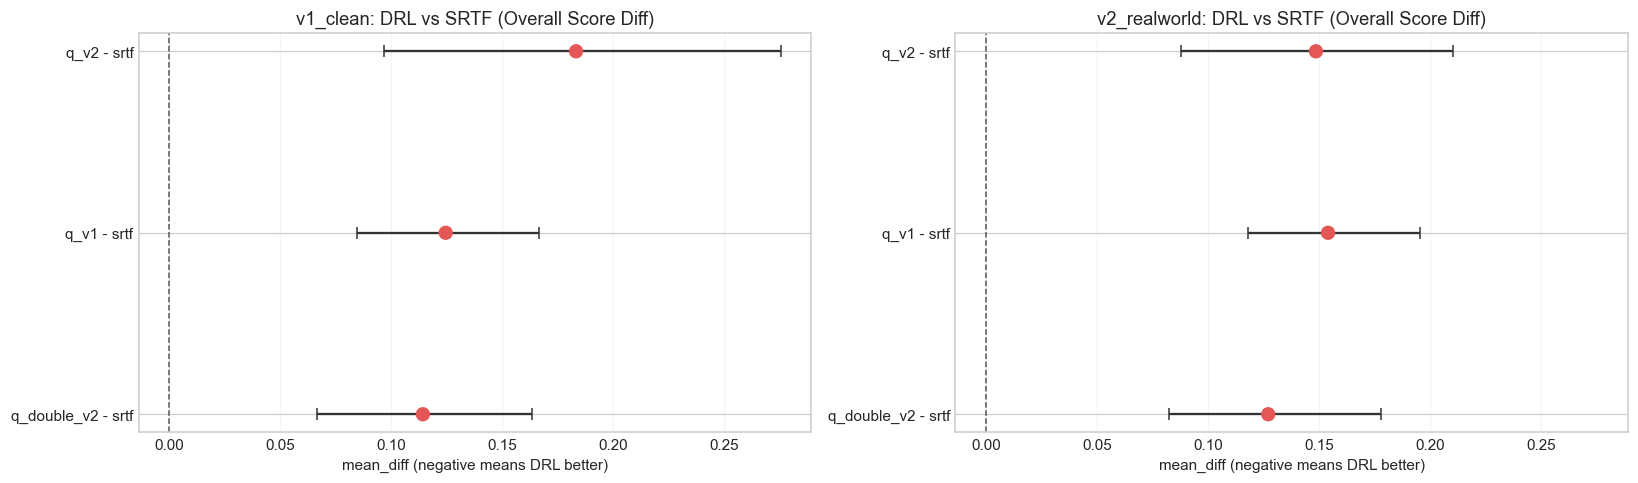

Saved artifacts:
 - ..\data\single_notebook_v1_v2_detail.csv
 - ..\data\single_notebook_v1_v2_scored.csv
 - ..\data\single_notebook_v1_v2_summary.csv
 - ..\data\single_notebook_v1_v2_hard_slice.csv
 - ..\data\single_notebook_v1_v2_significance.csv
Best policy on v1_clean: srtf (overall_score_mean=0.1215)
Best policy on v2_realworld: srtf (overall_score_mean=0.1187)


In [11]:
# Significance vs SRTF in hard slice
sig_rows = []
for track in ["v1_clean", "v2_realworld"]:
    t = hard_detail[hard_detail["dataset_track"] == track]
    for left in ["q_v1", "q_v2", "q_double_v2"]:
        a = t[t["policy"] == left]["overall_score"].values
        b = t[t["policy"] == "srtf"]["overall_score"].values
        if len(a) == 0 or len(b) == 0:
            continue
        obs, lo, hi, p = bootstrap_mean_diff_ci(a, b, n_boot=3000, seed=SEED)
        sig_rows.append({
            "dataset_track": track,
            "comparison": f"{left} - srtf",
            "mean_diff": obs,
            "ci95_low": lo,
            "ci95_high": hi,
            "p_boot_two_sided": p,
            "significant_95": not (lo <= 0.0 <= hi),
        })

sig_df = pd.DataFrame(sig_rows).sort_values(["dataset_track", "comparison"])
display(sig_df.round(6))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), dpi=110, sharex=True)
for idx, track in enumerate(["v1_clean", "v2_realworld"]):
    t = sig_df[sig_df["dataset_track"] == track].copy()
    if t.empty:
        axes[idx].set_title(f"{track}: no comparison data")
        continue

    y = np.arange(len(t))
    center = t["mean_diff"].to_numpy()
    lo_err = center - t["ci95_low"].to_numpy()
    hi_err = t["ci95_high"].to_numpy() - center

    colors = ["#54A24B" if v < 0 else "#E45756" for v in center]
    axes[idx].errorbar(center, y, xerr=[lo_err, hi_err], fmt="o", color="#333333", ecolor="#333333", capsize=4)
    axes[idx].scatter(center, y, c=colors, s=70, zorder=3)
    axes[idx].axvline(0.0, color="#555555", linestyle="--", linewidth=1)
    axes[idx].set_yticks(y)
    axes[idx].set_yticklabels(t["comparison"])
    axes[idx].set_title(f"{track}: DRL vs SRTF (Overall Score Diff)")
    axes[idx].set_xlabel("mean_diff (negative means DRL better)")
    axes[idx].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# Save all artifacts
detail_path = save_dir / "single_notebook_v1_v2_detail.csv"
scored_path = save_dir / "single_notebook_v1_v2_scored.csv"
summary_path = save_dir / "single_notebook_v1_v2_summary.csv"
hard_path = save_dir / "single_notebook_v1_v2_hard_slice.csv"
sig_path = save_dir / "single_notebook_v1_v2_significance.csv"

detail_all.to_csv(detail_path, index=False)
scored_all.to_csv(scored_path, index=False)
summary.to_csv(summary_path, index=False)
hard_summary.to_csv(hard_path, index=False)
sig_df.to_csv(sig_path, index=False)

print("Saved artifacts:")
print(" -", detail_path)
print(" -", scored_path)
print(" -", summary_path)
print(" -", hard_path)
print(" -", sig_path)

for track in ["v1_clean", "v2_realworld"]:
    t = hard_summary[hard_summary["dataset_track"] == track].sort_values("overall_score_mean")
    if len(t) > 0:
        best = t.iloc[0]
        print(f"Best policy on {track}: {best['policy']} (overall_score_mean={best['overall_score_mean']:.4f})")

## Reading the Visual Results

- If the v2_realworld leaderboard keeps a similar winner as v1_clean, your model is robust.
- If DRL drops sharply only on v2_realworld, it means domain-gap sensitivity.
- In significance plots, points left of zero are better than SRTF for overall score.
- Use saved CSV files in data/ for report tables and reproducible claims.

In [12]:
from pathlib import Path
from IPython.display import Markdown, display

required = ["hard_summary", "sig_df"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run earlier evaluation cells first. Missing variables: {missing}")

def get_row(track: str, policy: str):
    rows = hard_summary[(hard_summary["dataset_track"] == track) & (hard_summary["policy"] == policy)]
    return rows.iloc[0] if len(rows) > 0 else None

tracks = ["v1_clean", "v2_realworld"]
report_lines = []

for track in tracks:
    track_rows = hard_summary[hard_summary["dataset_track"] == track].sort_values("overall_score_mean")
    if track_rows.empty:
        continue

    best_row = track_rows.iloc[0]
    srtf_row = get_row(track, "srtf")
    drl_rows = track_rows[track_rows["policy"].str.startswith("q_")]
    best_drl = drl_rows.iloc[0] if len(drl_rows) > 0 else None

    line = []
    line.append(f"For {track}, the best overall policy is {best_row['policy']} with overall score {best_row['overall_score_mean']:.4f}.")

    if srtf_row is not None and best_drl is not None:
        gap = float(best_drl["overall_score_mean"] - srtf_row["overall_score_mean"])
        if gap > 0:
            line.append(
                f"The strongest DRL variant is {best_drl['policy']} at {best_drl['overall_score_mean']:.4f}, "
                f"which is worse than SRTF by {gap:.4f} on this lower-is-better metric."
            )
        else:
            line.append(
                f"The strongest DRL variant is {best_drl['policy']} at {best_drl['overall_score_mean']:.4f}, "
                f"which beats SRTF by {-gap:.4f}."
            )

        sig_track = sig_df[sig_df["dataset_track"] == track]
        drl_vs_srtf = sig_track[sig_track["comparison"].str.endswith("- srtf")]
        if len(drl_vs_srtf) > 0:
            n_sig = int(drl_vs_srtf["significant_95"].sum())
            line.append(
                f"Significance check: {n_sig}/{len(drl_vs_srtf)} DRL-vs-SRTF comparisons are statistically significant at 95% confidence."
            )

    report_lines.append(" ".join(line))

final_report = "\n\n".join(report_lines)

display(Markdown("## Plain-Language Summary"))
display(Markdown(final_report))

out_path = Path("../data/single_notebook_plain_language_report.txt")
out_path.write_text(final_report, encoding="utf-8")
print("Saved plain-language report to:", out_path)

## Plain-Language Summary

For v1_clean, the best overall policy is srtf with overall score 0.1215. The strongest DRL variant is q_double_v2 at 0.2357, which is worse than SRTF by 0.1142 on this lower-is-better metric. Significance check: 3/3 DRL-vs-SRTF comparisons are statistically significant at 95% confidence.

For v2_realworld, the best overall policy is srtf with overall score 0.1187. The strongest DRL variant is q_double_v2 at 0.2458, which is worse than SRTF by 0.1271 on this lower-is-better metric. Significance check: 3/3 DRL-vs-SRTF comparisons are statistically significant at 95% confidence.

Saved plain-language report to: ..\data\single_notebook_plain_language_report.txt


## Phase 2 Upgrade: Residual ML Switcher (Make DRL Competitive)

Goal: train a learned switcher that keeps SRTF latency strength but selectively uses carbon action only when the model predicts net benefit.

This block adds:
1. Lookahead-labeled training data for action choice (carbon vs SRTF).
2. Random-forest policy switcher training for each dataset track.
3. Threshold and safety guard tuning to maximize hard-slice overall score.
4. Final benchmark against SRTF and q_double_v2 with significance checks.

In [13]:
import copy
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm

def lookahead_return(env: SimpleClusterEnv, first_action: int, horizon: int = 6, gamma: float = 0.97) -> float:
    e = copy.deepcopy(env)
    total = 0.0
    disc = 1.0
    done = False

    for t in range(horizon):
        action = first_action if t == 0 else 2  # fallback to SRTF after first action
        _, reward, done, _ = e.step(action)
        total += disc * reward
        disc *= gamma
        if done:
            break
    return total


def build_switch_training_data(
    df: pd.DataFrame,
    episodes: int = 20,
    sample_prob: float = 0.55,
    lookahead: int = 6,
    dirty_quantile: float = 0.85,
    seed_base: int = 220_000,
):
    X, y = [], []

    for ep in tqdm(range(episodes), desc=f"Build switch data ({seed_base})", unit="ep", leave=False):
        rng = np.random.default_rng(seed_base + ep)
        congestion = str(rng.choice(["moderate", "high"], p=[0.35, 0.65]))
        noise = float(rng.choice([10.0, 15.0, 20.0, 25.0], p=[0.20, 0.30, 0.35, 0.15]))
        capacity = int(rng.choice([6, 8], p=[0.75, 0.25]))

        jobs = build_jobs(congestion, HORIZON_STEPS, rng, "dataset", df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)

        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
        state = env.reset()
        done = False

        while not done:
            if rng.random() < sample_prob:
                ci_now = env.curve[min(env.step_idx, env.max_step - 1)]
                ci_dirty = 1.0 if ci_now >= float(np.quantile(env.curve, dirty_quantile)) else 0.0
                feat = [float(state[0]), float(state[1]), float(state[2]), float(state[3]), float(state[4]), ci_dirty]

                v_carbon = lookahead_return(env, first_action=1, horizon=lookahead, gamma=0.97)
                v_srtf = lookahead_return(env, first_action=2, horizon=lookahead, gamma=0.97)
                label = 1 if v_carbon > v_srtf else 0

                X.append(feat)
                y.append(label)

            # behavior policy: mostly srtf with occasional carbon exploration
            behavior_action = 2 if rng.random() < 0.88 else 1
            state, _, done, _ = env.step(behavior_action)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int32)
    if len(X) == 0:
        raise RuntimeError("No training samples were generated for switcher")
    return X, y


def train_residual_switcher(df: pd.DataFrame, episodes: int, seed_base: int):
    X, y = build_switch_training_data(df=df, episodes=episodes, seed_base=seed_base)
    label_counts = pd.Series(y).value_counts().sort_index()

    if len(label_counts) < 2:
        # Fallback if one-sided labels appear in small sample.
        X2, y2 = build_switch_training_data(df=df, episodes=max(episodes + 8, 24), seed_base=seed_base + 5_000)
        X = np.concatenate([X, X2], axis=0)
        y = np.concatenate([y, y2], axis=0)
        label_counts = pd.Series(y).value_counts().sort_index()

    model = RandomForestClassifier(
        n_estimators=260,
        max_depth=10,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )
    model.fit(X, y)
    train_acc = float((model.predict(X) == y).mean())

    stats = {
        "samples": int(len(X)),
        "label_0_srtf_count": int(label_counts.get(0, 0)),
        "label_1_carbon_count": int(label_counts.get(1, 0)),
        "train_accuracy": train_acc,
    }
    return model, stats


switch_model_v1, switch_stats_v1 = train_residual_switcher(v1_df, episodes=20, seed_base=220_000)
switch_model_v2, switch_stats_v2 = train_residual_switcher(v2_df, episodes=24, seed_base=250_000)

display(pd.DataFrame([
    {"dataset_track": "v1_clean", **switch_stats_v1},
    {"dataset_track": "v2_realworld", **switch_stats_v2},
]).round(4))

,dataset_track,samples,label_0_srtf_count,label_1_carbon_count,train_accuracy
0,v1_clean,3205,1715,1490,0.8184
1,v2_realworld,3887,2078,1809,0.8032


In [15]:
from tqdm import tqdm

def run_ml_switch_policy(
    df: pd.DataFrame,
    model: RandomForestClassifier,
    seed: int,
    noise_pct: float,
    congestion: str,
    capacity: int,
    prob_threshold: float = 0.62,
    wait_guard: float = 0.58,
    dirty_quantile: float = 0.85,
):
    rng = np.random.default_rng(seed)
    jobs = build_jobs(congestion, HORIZON_STEPS, rng, "dataset", df)
    jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
    curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise_pct)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
    state = env.reset()
    done = False
    carbon_actions = 0
    steps = 0
    dirty_threshold = float(np.quantile(env.curve, dirty_quantile))

    # Predicting per step is much faster with single-thread inference.
    if getattr(model, "n_jobs", 1) != 1:
        model.set_params(n_jobs=1)

    while not done:
        ci_now = env.curve[min(env.step_idx, env.max_step - 1)]
        ci_dirty = 1.0 if ci_now >= dirty_threshold else 0.0
        feat = np.array([float(state[0]), float(state[1]), float(state[2]), float(state[3]), float(state[4]), ci_dirty], dtype=np.float32).reshape(1, -1)
        p_carbon = float(model.predict_proba(feat)[0, 1])

        # Safety-first guard: when queue stress is high, force SRTF.
        if float(state[3]) >= wait_guard:
            action = 2
        elif p_carbon >= prob_threshold:
            action = 1
            carbon_actions += 1
        else:
            action = 2

        state, _, done, _ = env.step(action)
        steps += 1

    out = env.metrics()
    out.update({
        "policy": "ml_switch_rf",
        "seed": seed,
        "noise_pct": noise_pct,
        "congestion": congestion,
        "capacity": capacity,
        "switch_prob_threshold": prob_threshold,
        "switch_wait_guard": wait_guard,
        "carbon_action_share": carbon_actions / max(1, steps),
    })
    return out


def tune_switch_params(df: pd.DataFrame, model: RandomForestClassifier, track_name: str):
    thresholds = [0.55, 0.60, 0.65, 0.70, 0.75]
    guards = [0.45, 0.55, 0.65]
    rows = []
    param_grid = [(th, wg) for th in thresholds for wg in guards]

    for th, wg in tqdm(param_grid, desc=f"Tuning {track_name}", unit="cfg"):
        detail_rows = []
        for seed in tqdm(range(6), desc=f"{track_name} seeds", leave=False, unit="seed"):
            detail_rows.append(run_policy_inference(df, "srtf", seed, None, 20.0, "high", 6, reward_weights=OVERALL_WEIGHTS))
            detail_rows.append(run_ml_switch_policy(df, model, seed, 20.0, "high", 6, prob_threshold=th, wait_guard=wg))

        tmp = pd.DataFrame(detail_rows)
        tmp["dataset_track"] = track_name
        tmp_scored = compute_overall_score_robust(tmp, OVERALL_WEIGHTS)
        srtf_score = float(tmp_scored[tmp_scored["policy"] == "srtf"]["overall_score"].mean())
        ml_score = float(tmp_scored[tmp_scored["policy"] == "ml_switch_rf"]["overall_score"].mean())

        rows.append({
            "dataset_track": track_name,
            "prob_threshold": th,
            "wait_guard": wg,
            "srtf_overall": srtf_score,
            "ml_overall": ml_score,
            "ml_minus_srtf": ml_score - srtf_score,
        })

    tune_df = pd.DataFrame(rows).sort_values("ml_minus_srtf")
    best = tune_df.iloc[0].to_dict()
    return tune_df, best


tune_v1, best_v1 = tune_switch_params(v1_df, switch_model_v1, "v1_clean")
tune_v2, best_v2 = tune_switch_params(v2_df, switch_model_v2, "v2_realworld")

display(pd.concat([tune_v1.head(5), tune_v2.head(5)], ignore_index=True).round(5))
print("Best v1 params:", best_v1)
print("Best v2 params:", best_v2)

c:\Users\ANISH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Tuning v2_realworld: 100%|██████████| 15/15 [08:56<00:00, 35.77s/cfg]


,dataset_track,prob_threshold,wait_guard,srtf_overall,ml_overall,ml_minus_srtf
0,v1_clean,0.70,0.45,0.40833,0.55000,0.14167
1,v1_clean,0.70,0.65,0.41667,0.58333,0.16667
2,v1_clean,0.70,0.55,0.39167,0.60833,0.21667
3,v1_clean,0.75,0.45,0.30000,0.53333,0.23333
4,v1_clean,0.65,0.45,0.35833,0.60000,0.24167
5,v2_realworld,0.70,0.45,0.37500,0.37500,0.00000
6,v2_realworld,0.75,0.55,0.30000,0.32500,0.02500
7,v2_realworld,0.75,0.45,0.15000,0.18333,0.03333
8,v2_realworld,0.70,0.55,0.45000,0.50833,0.05833
9,v2_realworld,0.70,0.65,0.45000,0.50833,0.05833


Best v1 params: {'dataset_track': 'v1_clean', 'prob_threshold': 0.7, 'wait_guard': 0.45, 'srtf_overall': 0.4083333333333334, 'ml_overall': 0.5499999999999999, 'ml_minus_srtf': 0.14166666666666655}
Best v2 params: {'dataset_track': 'v2_realworld', 'prob_threshold': 0.7, 'wait_guard': 0.45, 'srtf_overall': 0.375, 'ml_overall': 0.375, 'ml_minus_srtf': 0.0}


Final ml-switch benchmark: 100%|██████████| 192/192 [19:10<00:00,  5.99s/run]

Hard-slice leaderboard with residual switcher:


,dataset_track,policy,overall_score_mean,overall_score_ci95,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,jobs_completed_mean
52,v1_clean,srtf,0.1246,0.0063,0.2715,1.0614,4.7705,220.3333
20,v1_clean,ml_switch_rf,0.1258,0.0054,0.2713,1.0950,4.8111,220.0000
28,v1_clean,q_double_v2,0.2382,0.0506,0.2821,1.7820,6.4486,208.5000
36,v1_clean,q_v1,0.2486,0.0433,0.2738,1.8953,7.0924,208.6667
44,v1_clean,q_v2,0.3069,0.0930,0.2896,2.2009,7.3767,204.5000
12,v1_clean,fcfs,0.7678,0.0210,0.4738,4.5699,10.7201,123.2500
4,v1_clean,carbon,0.8139,0.0212,0.4281,3.9733,11.8826,130.5000
108,v2_realworld,srtf,0.1177,0.0057,0.3474,1.0911,4.6944,218.0000
76,v2_realworld,ml_switch_rf,0.1287,0.0130,0.3457,1.1354,4.8448,217.9167
84,v2_realworld,q_double_v2,0.2462,0.0489,0.3607,1.8448,6.5969,204.7500


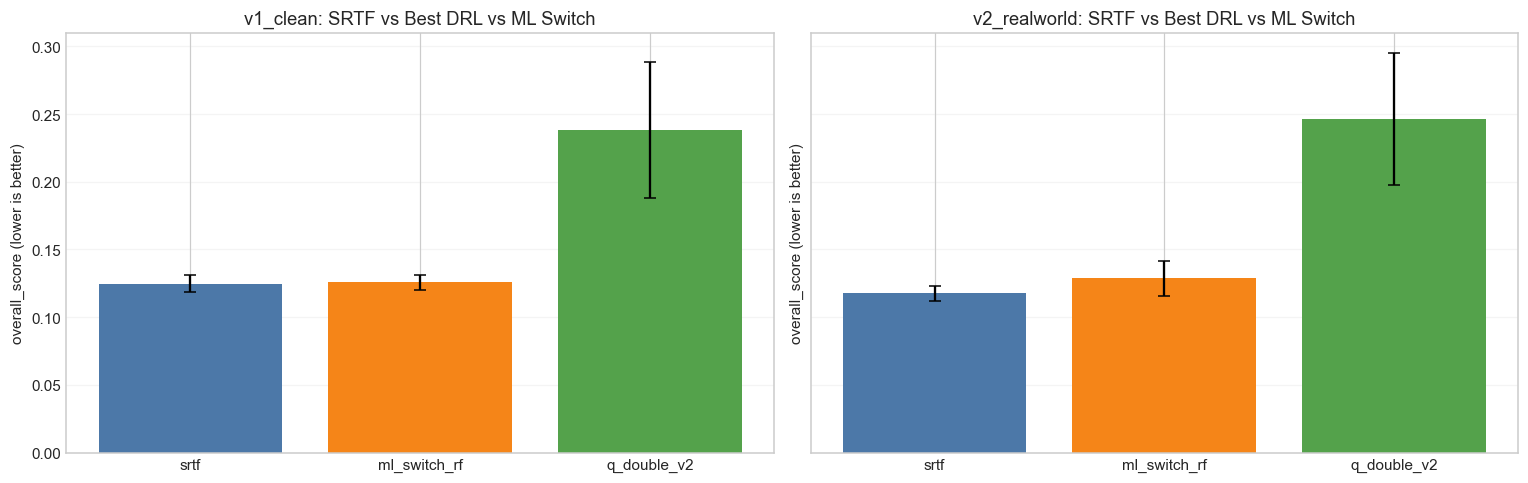

,dataset_track,comparison,mean_diff,ci95_low,ci95_high,p_boot_two_sided,significant_95
0,v1_clean,ml_switch_rf - srtf,0.001183,-0.007017,0.008901,0.7545,False
1,v2_realworld,ml_switch_rf - srtf,0.011000,-0.000780,0.026264,0.0820,False


In [16]:
from itertools import product
from tqdm import tqdm

ml_rows = []
all_combos = list(product(eval_cfg["seeds"], eval_cfg["noises"], eval_cfg["congestions"], eval_cfg["capacities"]))

with tqdm(total=len(all_combos) * 2, desc="Final ml-switch benchmark", unit="run") as pbar:
    for seed, noise, cong, cap in all_combos:
        ml_rows.append(
            {
                **run_ml_switch_policy(
                    v1_df,
                    switch_model_v1,
                    seed,
                    noise,
                    cong,
                    cap,
                    prob_threshold=float(best_v1["prob_threshold"]),
                    wait_guard=float(best_v1["wait_guard"]),
                ),
                "dataset_track": "v1_clean",
            }
        )
        pbar.update(1)

        ml_rows.append(
            {
                **run_ml_switch_policy(
                    v2_df,
                    switch_model_v2,
                    seed,
                    noise,
                    cong,
                    cap,
                    prob_threshold=float(best_v2["prob_threshold"]),
                    wait_guard=float(best_v2["wait_guard"]),
                ),
                "dataset_track": "v2_realworld",
            }
        )
        pbar.update(1)

ml_detail = pd.DataFrame(ml_rows)
detail_plus = pd.concat([detail_all, ml_detail], ignore_index=True)
scored_plus = compute_overall_score_robust(detail_plus, OVERALL_WEIGHTS)

summary_plus = (
    scored_plus.groupby(["dataset_track", "policy", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg(
        n=("seed", "count"),
        overall_score_mean=("overall_score", "mean"),
        overall_score_std=("overall_score", "std"),
        carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
        avg_jct_mean=("avg_jct_h", "mean"),
        tail_jct_mean=("tail_jct_h", "mean"),
        jobs_completed_mean=("jobs_completed", "mean"),
    )
)
summary_plus["overall_score_ci95"] = 1.96 * summary_plus["overall_score_std"].fillna(0.0) / np.sqrt(summary_plus["n"].clip(lower=1))

hard_plus = (
    summary_plus[
        (summary_plus["noise_pct"] == 20.0)
        & (summary_plus["congestion"] == "high")
        & (summary_plus["capacity"] == 6)
    ]
    .copy()
    .sort_values(["dataset_track", "overall_score_mean"])
    )

print("Hard-slice leaderboard with residual switcher:")
display(hard_plus[[
    "dataset_track", "policy", "overall_score_mean", "overall_score_ci95",
    "carbon_per_completed_job_mean", "avg_jct_mean", "tail_jct_mean", "jobs_completed_mean",
]].round(4))

focus_policies = ["srtf", "q_double_v2", "ml_switch_rf"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=110, sharey=True)
for idx, track in enumerate(["v1_clean", "v2_realworld"]):
    t = hard_plus[(hard_plus["dataset_track"] == track) & (hard_plus["policy"].isin(focus_policies))].copy()
    t = t.sort_values("overall_score_mean")
    axes[idx].bar(t["policy"], t["overall_score_mean"], yerr=t["overall_score_ci95"], capsize=4, color=["#4C78A8", "#F58518", "#54A24B"])
    axes[idx].set_title(f"{track}: SRTF vs Best DRL vs ML Switch")
    axes[idx].set_ylabel("overall_score (lower is better)")
    axes[idx].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

sig_switch_rows = []
for track in ["v1_clean", "v2_realworld"]:
    t = scored_plus[
        (scored_plus["dataset_track"] == track)
        & (scored_plus["noise_pct"] == 20.0)
        & (scored_plus["congestion"] == "high")
        & (scored_plus["capacity"] == 6)
    ]
    a = t[t["policy"] == "ml_switch_rf"]["overall_score"].values
    b = t[t["policy"] == "srtf"]["overall_score"].values
    if len(a) == 0 or len(b) == 0:
        continue
    obs, lo, hi, p = bootstrap_mean_diff_ci(a, b, n_boot=4000, seed=SEED)
    sig_switch_rows.append({
        "dataset_track": track,
        "comparison": "ml_switch_rf - srtf",
        "mean_diff": obs,
        "ci95_low": lo,
        "ci95_high": hi,
        "p_boot_two_sided": p,
        "significant_95": not (lo <= 0.0 <= hi),
    })

sig_switch_df = pd.DataFrame(sig_switch_rows)
display(sig_switch_df.round(6))   